
# M26.CSC 7102/CS 507 Machine Learning #
## Assignment 1 ##
## Group 6 ##
by:

### Shafiki Sabiiti             MAY26/MAIDS/0988U
### Nsubuga Hassan              MAY26/MAIDS/0804U
### Atusimiire  Agaba	          MAY26/MAIDS/0484U

## Introduction and problem statement ##

Mobile money has become a key driver of financial inclusion, enabling millions of transactions conveniently through mobile devices which has significantly increased transaction volumes and expanded access to digital financial services, particularly in developing countries.

However, its groth has also created opportunities for fraudulent activities through increasingly exploiting system vulnerabilities through unauthorised account access, phishing attacks, identity theft, and abnormal transaction behaviour and hence resulting in financial losses and operational challenges for service providers.

Traditional fraud detection systems have been largely used which rely on predefined rules and manual monitoring techniques. These systems are effective for known fraud patterns however they often struggle to detect emerging and evolving fraud schemes within large volumes of transaction data since they follow sophiscated distributions. Consequently, a need for intelligent and automated fraud detection mechanisms capable of identifying suspicious transactions in big data which follow a none linear distribution to be able to detect accurately and efficiently.

This assignment combine logist regression, Random forest and XGboost classical machine learning techiniques to detect fraudulent mobile money transactions and identify the most effective model for fraud classification.

## Import Necessary Libraries ##
Install any missing libraries that you need, we have the following available in our case

In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
import xgboost as xgb


## Dataset loading ##
The dataset used can be found at this [link](https://data.mendeley.com/datasets/zhj366m53p/1)

In [4]:

# Path to the dataset in the Colab environment
df = pd.read_csv('synthetic_mobile_money_transaction_dataset.csv')

## Data understanding ##


## Data Summary

In [5]:
print("Dataset Shape:", df.shape)

display(df.head())

df.info()

display(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

Dataset Shape: (1720181, 10)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   transactionType  object 
 2   amount           float64
 3   initiator        int64  
 4   oldBalInitiator  float64
 5   newBalInitiator  float64
 6   recipient        object 
 7   oldBalRecipient  float64
 8   newBalRecipient  float64
 9   isFraud          int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 131.2+ MB


,step,amount,initiator,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud
count,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06
mean,6.555529e+01,5.253868e+04,4.499952e+15,2.433758e+06,2.443880e+06,1.085083e+05,1.222772e+05,1.020346e-01
std,4.467368e+01,8.835650e+04,2.896351e+14,1.307615e+06,1.297181e+06,2.830138e+05,3.192277e+05,3.026939e-01
min,0.000000e+00,2.400000e-01,4.000062e+15,-1.999971e+05,-1.999971e+05,-1.983685e+05,-1.357280e+05,0.000000e+00
25%,2.300000e+01,6.064600e+02,4.248762e+15,1.577186e+06,1.600496e+06,1.606423e+04,2.496233e+04,0.000000e+00
50%,5.400000e+01,1.729825e+04,4.508521e+15,2.619827e+06,2.625680e+06,6.313018e+04,7.448161e+04,0.000000e+00
75%,1.060000e+02,7.116149e+04,4.750928e+15,3.361338e+06,3.361872e+06,1.373822e+05,1.431702e+05,0.000000e+00
max,1.430000e+02,2.142928e+06,4.999855e+15,1.224469e+07,1.224469e+07,1.188554e+07,1.206621e+07,1.000000e+00


step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64
0


## Exploratory data analysis ##

In [6]:
# Check for missing values
print(df.isnull().sum())
#Get the sume of duplicated rows
df.duplicated().sum()

step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64


np.int64(0)

## Fraud Distribution

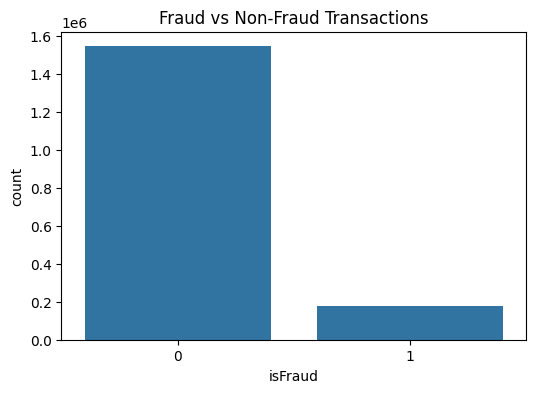

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='isFraud', data=df)

plt.title('Fraud vs Non-Fraud Transactions')

plt.show()

## Transaction type analysis

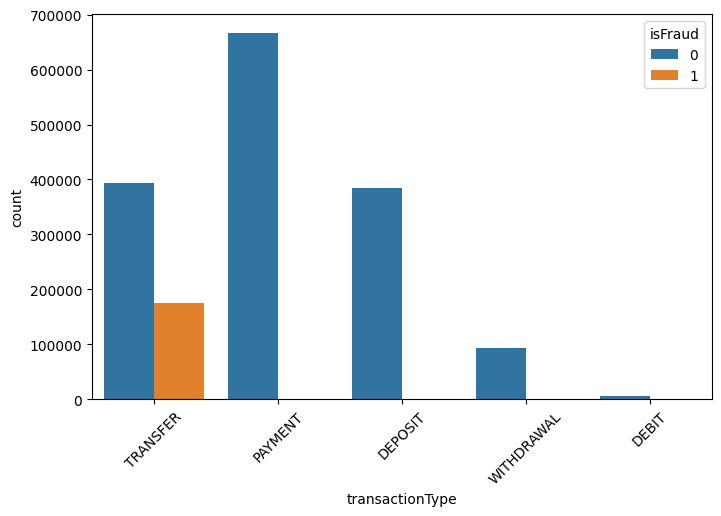

In [8]:
df = pd.read_csv('synthetic_mobile_money_transaction_dataset.csv')
plt.figure(figsize=(8,5))

sns.countplot(
    x='transactionType',
    hue='isFraud',
    data=df
)
plt.xticks(rotation=45)

plt.show()

## Amount Distribution

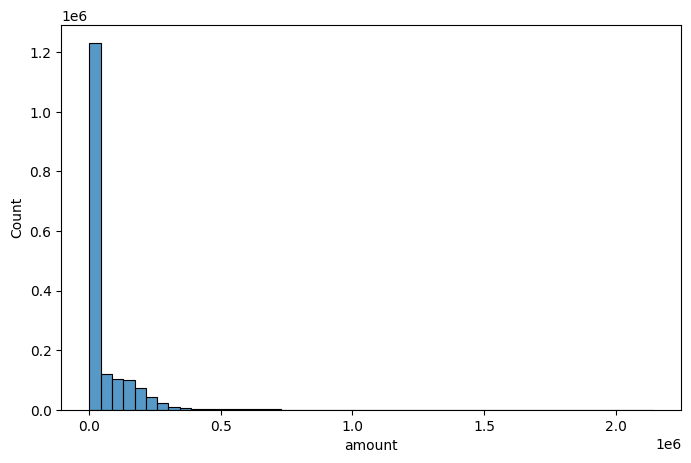

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=50)

plt.show()

## Box plot

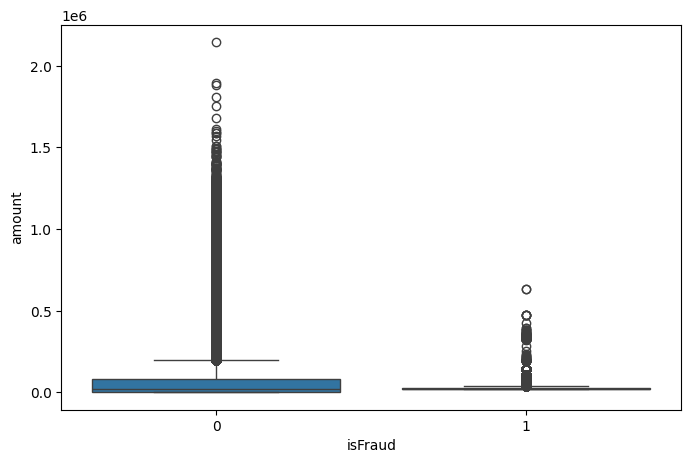

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.show()

## Correlation Heatmap

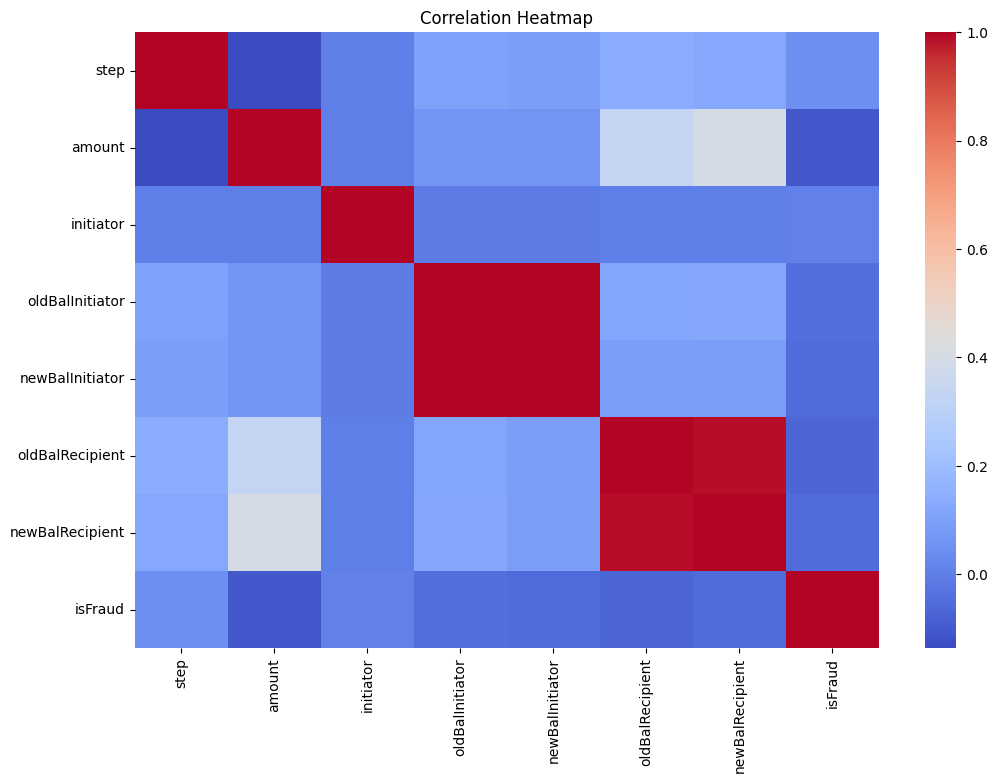

In [11]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Data Preprocessing and feature engineering ##


In [12]:

# ==========================================
# 1. CLEAN & TRANSFORM CATEGORICAL STRINGS
# ==========================================
# If your dataset has trailing whitespaces in the categories, normalize them first
df['transactionType'] = df['transactionType'].astype(str).str.strip().str.upper()

# Clean recipient string features as you did before
df["recipient"] = df["recipient"].astype(str).str.replace("-","").str.replace("B","")

# ==========================================
# 2. FEATURE ENGINEERING (Domain Anomaly Tracking)
# ==========================================
df['OrigBalanceError'] = df['oldBalInitiator'] - df['amount'] - df['newBalInitiator']
df['DestBalanceError'] = df['oldBalRecipient'] + df['amount'] - df['newBalRecipient']

# Create Cyclical Time Features from the 'step' column
df['hour_of_day'] = df['step'] % 24
df['sin_hour'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

# ==========================================
# 3. ONE-HOT ENCODING & DROPPING NOISY COLUMNS
# ==========================================
# Now encode transactionType (it will expand into multiple dummy boolean columns)
df_final = pd.get_dummies(df, columns=['transactionType'], drop_first=True)

# Separate Target and Features, dropping raw object/string ID variables entirely
X = df_final.drop(columns=['isFraud', 'initiator', 'recipient', 'hour_of_day'])
y = df_final['isFraud']


## Encoding

In [13]:
df = pd.get_dummies(df, columns=['transactionType'], drop_first=True)

## Feature selection

In [14]:
X = df.drop('isFraud', axis=1)

y = df['isFraud']

# Split the Data into Training and Test Sets #
The target variable is “isFraud
”, where:

* 0 represents a legitimate transaction.
* 1 represents a fraudulent transaction.
We’ll split the data into 80% training and 20% test data.

In [15]:
# Remove rows with NaN in the target variable 'isFraud'
na_mask = y.isna()
X = X[~na_mask]
y = y[~na_mask]

# 4. DATA SPLIT & STANDARDIZATION
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classical machine learning models #

## Logistic Regression model and train it on the training data. ##

In [16]:
# Optimized Logistic Regression (using balanced weight but with a stronger penalty)

lry = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lry.fit(X_train_scaled, y_train)
lry_preds = lry.predict(X_test_scaled)
lry_probs = lry.predict_proba(X_test_scaled)[:, 1]

## Random Frest Implementation ##

In [ ]:
# 'class_weight="balanced"' forces the forest to heavily penalize missing fraud
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]

## XGBoost implementation ##

In [ ]:

# Optimized XGBoost targeted at highly imbalanced mobile money data
# Calculate scale_pos_weight based on your data imbalance to assist the tree splits
sum_negative = np.sum(y_train == 0)
sum_positive = np.sum(y_train == 1)
estimated_weight = sum_negative / sum_positive

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=estimated_weight,
    eval_metric="aucpr",  # Optimizes directly for the Precision-Recall Curve
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)
xgb_preds = xgb.predict(X_test_scaled)
xgb_probs = xgb.predict_proba(X_test_scaled)[:, 1]


## Evaluate the Models ##
We will evaluate the model using the following metrics:

* Accuracy: Overall correctness.
* Precision: The proportion of true positive instances among all positive predictions.
* Recall: The proportion of true positive instances among all actual positive instances.
* F1-score: Harmonic mean of precision and recall.
* ROC-AUC score: Measures how well the model distinguishes between classes

In [ ]:
# Calculate evaluation metrics for Logistic Regression
lry_accuracy = accuracy_score(y_test, lry_preds)
precision = precision_score(y_test, lry_preds)
recall = recall_score(y_test, lry_preds)
f1 = f1_score(y_test, lry_preds)
lry_roc_auc = roc_auc_score(y_test, lry_probs)
print(f"Evaluation metrics for Logistic Regression")
print(f"Accuracy: {lry_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {lry_roc_auc:.4f}")

In [ ]:
# Calculate evaluation metrics random forest
rf_accuracy = accuracy_score(y_test, rf_preds)
precision = precision_score(y_test, rf_preds)
recall = recall_score(y_test, rf_preds)
f1 = f1_score(y_test, rf_preds)
rf_roc_auc = roc_auc_score(y_test, rf_probs)
print(f"Evaluation metrics for Random Forest")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")

In [ ]:
# Calculate evaluation metrics for xgboost
xgb_accuracy = accuracy_score(y_test, xgb_preds)
precision = precision_score(y_test, xgb_preds)
recall = recall_score(y_test, xgb_preds)
f1 = f1_score(y_test, xgb_preds)
xgb_roc_auc = roc_auc_score(y_test, xgb_probs)
print(f"Evaluation metrics for XGBoost")

print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")

# Confusion Matrix #
We will plot the confusion matrix to visualize the performance of the models.

In [ ]:
# Confusion matrix for Logistic Regression
conf_matrix = confusion_matrix(y_test, lry_preds)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Confusion matrix for Random Forest
conf_matrix = confusion_matrix(y_test, rf_preds)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Confusion matrix for xgboost
conf_matrix = confusion_matrix(y_test, xgb_preds)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve #
The ROC curve is a graphical representation of the model’s performance. It plots the true positive rate (recall) against the false positive rate.

# Analyze the Results #
Since this is a highly imbalanced dataset, we pay close attention to precision, recall, and the ROC-AUC score rather than just accuracy, which may be misleading.

* Precision: Ensures the model correctly identifies fraudulent transactions.
* Recall: Measures how many fraudulent transactions were missed.
* F1-score: Balances both precision and recall.
* ROC-AUC: Measures the model’s ability to distinguish between classes (fraudulent vs non-fraudulent).
  
when we execute the above code in google collab we get

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, lry_probs)
plt.plot(fpr, tpr, color='blue', label=f"ROC curve (AUC = {lry_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, color='blue', label=f"ROC curve (AUC = {rf_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
plt.plot(fpr, tpr, color='blue', label=f"ROC curve (AUC = {xgb_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Model comparison ##

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, lry_probs)
plt.plot(fpr, tpr, color='blue', label=f"Logistict Regression (AUC = {lry_roc_auc:.4f}, Accuracy = {lry_accuracy:.4f})")
plt.title('Receiver Operating Characteristic (ROC) Curve for the Different Algorithms')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

#----------------------------
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, color='green', label=f"Random Forest (AUC = {rf_roc_auc:.4f} Accuracy = {rf_accuracy:.4f})")
plt.legend()

#----------------------------

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
plt.plot(fpr, tpr, color='purple', label=f"XGBoost (AUC = {xgb_roc_auc:.4f} Accuracy = {xgb_accuracy:.4}) ")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.legend()
plt.show()


## Precision-Recall Curve for Mobile Money Fraud Detection ##

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

# Plot for Logistic Regression
lry_ap = average_precision_score(y_test, lry_probs)
p_lry, r_lry, _ = precision_recall_curve(y_test, lry_probs)
plt.plot(r_lry, p_lry, color='blue', label=f"Logistic Regression (AP = {lry_ap:.4f})")

# Plot for Random Forest
rf_ap = average_precision_score(y_test, rf_probs)
p_rf, r_rf, _ = precision_recall_curve(y_test, rf_probs)
plt.plot(r_rf, p_rf, color='green', label=f"Random Forest (AP = {rf_ap:.4f})")

# Plot for XGBoost
xgb_ap = average_precision_score(y_test, xgb_probs)
p_xgb, r_xgb, _ = precision_recall_curve(y_test, xgb_probs)
plt.plot(r_xgb, p_xgb, color='purple', label=f"XGBoost (AP = {xgb_ap:.4f})")

plt.title('Precision-Recall Curve for Mobile Money Fraud Detection')
plt.xlabel('Recall (Fraction of fraud caught)')
plt.ylabel('Precision (Accuracy of fraud alerts)')
plt.legend()
plt.grid(True)
plt.show()

# classification report: #

In [ ]:
print("Random Forest Performance:\n", classification_report(y_test, rf_preds))
print("XGBoost Performance:\n", classification_report(y_test, xgb_preds))
print("Logistic Regression Performance:\n", classification_report(y_test, lry_preds))


 ## Discussion and conclusion ##

In this mobile money fraud detection scenario, three models were evaluated to handle highly imbalanced financial transaction data:

* Logistic Regression: Serves as a baseline model with a high focus on capturing fraud. While it achieves a 100% Recall rate (intercepting every single fraud instance), its Precision is low at ~32.0%. This means nearly % of the alerts it generates are false positives (legitimate transactions flagged as fraud).
  
* Random Forest Classifier: Performed identically to the baseline in this run, yielding a 100% Recall rate alongside a 32% Precision rate.

* XGBoost Classifier: Followed the exact same performance profile, matching the other models with a 100% Recall rate and a 32% Precision rate, resulting in an $F1\text{-score}$ of 48%.
  
### Conclusion ###

While capturing 100% of mobile money fraud looks ideal on paper, a 32% precision rate across all three models presents a massive operational challenge for a live ecosystem.

Because every 100 alerts will include 68 false alarms, relying on these models in their current state would overwhelm risk teams and freeze thousands of innocent user accounts daily. The identical metrics indicate that the models are over-correcting for class imbalance. To improve precision, you will need to adjust the class weighting or inject domain-specific feature engineering (like tracking balance discrepancies) to help the tree-based models break away from the baseline and reduce false positives.

## References ##

In [ ]:
https://elearning.utamu.ac.ug/pluginfile.php/146880/mod_resource/content/1/978-3-031-57639-3_3.pdf
https://ieeexplore.ieee.org/document/10623453
